In [1]:
# Version for filename
ver = 'GRU'  # GRU or LSTM

date = "250804"
rnn_folder = f"D:/Python_TK_3/datas/{date}_DL"

shap_number = "VisStim_evoked_01"
#os.mkdir(f"{rnn_folder}/shap{shap_number}")

In [2]:
import numpy as np

cnn_testX  = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_cnn_detailed_test_features.npy")


date = "250804"
mixed_dataset = "ss-visStim_evoked_01"
testY  = np.load(f"{rnn_folder}/model_{mixed_dataset}/{date}_{mixed_dataset}_test_targets.npy")


print(cnn_testX.shape, testY.shape)

(384, 11, 67584) (384,)


In [3]:
fs = 20  # サンプリング周波数
frames = 90 # frames per experiments
first_ex = 0
last_ex = 58
NumberOfDatas = last_ex - first_ex + 1        # number of experiments
start_stim = 20
stop_stim = 20.5
start_ave= 10
end_ave= 20
look_frame = 10     

In [4]:
# Ignore warning
import os
import tensorflow as tf
import logging
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)
tf.get_logger().setLevel('INFO')
tf.autograph.set_verbosity(0)
tf.get_logger().setLevel(logging.ERROR)

import numpy
#import pandas
import matplotlib.pyplot as plt
from scipy import io
from tensorflow.keras import layers, losses, optimizers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, ConvLSTM2D, Bidirectional
from sklearn.metrics import roc_curve
from sklearn.metrics import auc, roc_auc_score

In [5]:
# Allow grouth option of GPU
import tensorflow as tf
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config=config)

In [6]:
# Clear session
from keras import backend as K
K.clear_session()

Using TensorFlow backend.


In [7]:
plt.rcParams["font.size"] = 18

In [8]:
# Data allocation from experiment No.
TRAIN = list(range(24))
VALID = list(range(8))
TEST  = list(range(8))

In [9]:
# Callback Setting
model_file_path = f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_best_model_{ver}.h5"

In [10]:
#input_train = cnn_trainX
#input_valid = cnn_validX
input_test  = cnn_testX

In [11]:
model = load_model(model_file_path)

In [12]:
#model = load_model("D:/Python_TK_3/datas/250422_RNN/shap01/250422_01_best_model_GRU.h5")

In [13]:
# Calcurate accuracy
model.evaluate(input_test,testY)

384/384 [==============================] - 1s 4ms/sample - loss: 0.3742 - acc: 0.8568


[0.37420569608608883, 0.8567708]

In [14]:
# Predict
#train_pred = model.predict(input_train)
#valid_pred = model.predict(input_valid)
test_pred = model.predict(input_test)

In [15]:
# Label
#train_target = trainY
#valid_target = validY
test_target = testY

In [16]:
prediction_frames = 24
print(prediction_frames)

24


In [17]:
# 初期値
start_value = 0.0 + (look_frame/fs)

# 増加量
increment = 1/fs

# 繰り返し回数
count = prediction_frames

# リストを生成
t = [start_value + i * increment for i in range(count)]

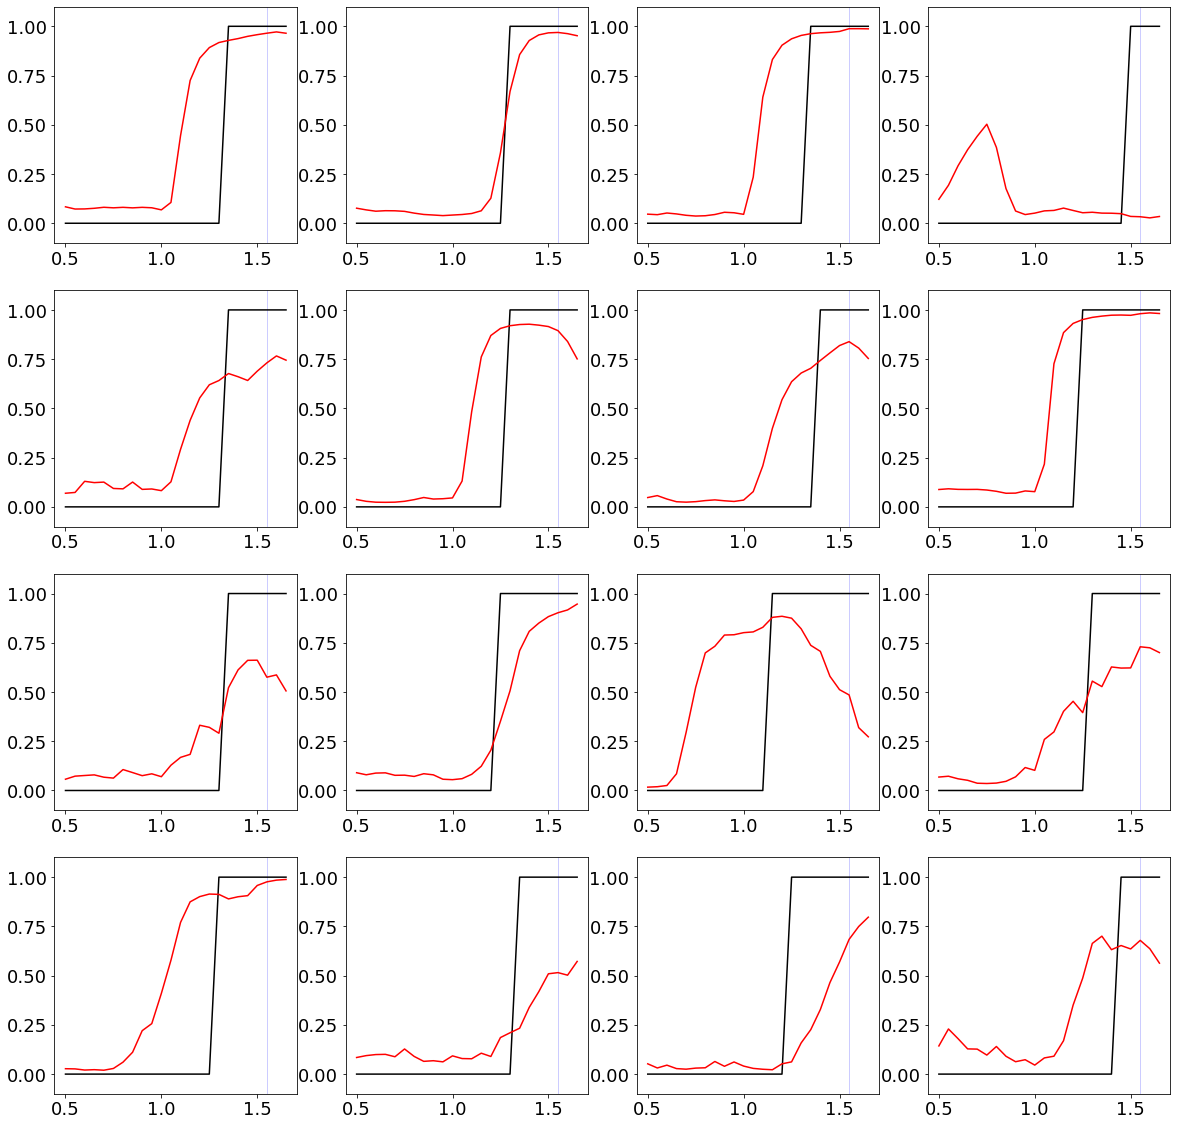

In [18]:
plt.figure(figsize=(20, 20))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(test_target.shape[0]/prediction_frames)):
    plt.subplot(4, 4, ex+1)
    plt.plot(t, test_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, test_pred[ex*prediction_frames:(ex+1)*prediction_frames, 0], color='red')
    plt.axvspan(1.55, 1.55, color='blue', alpha=0.2)
    plt.ylim(-0.1, 1.1)
    
plt.show()

In [19]:
# Plot ROC curve
def plot_roc(y_pred, y_test, mode):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=1)
    AUC = roc_auc_score(y_test, y_pred)
    plt.plot(fpr, tpr, label="AUC = {:.3f}".format(AUC))
    plt.title(mode + " ROC curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()
    print('AUC: {:.3f}'.format(AUC))
    opt_thr = thresholds[numpy.argmax(tpr - fpr)]
    print('Optimal threshold: {:.3f}'.format(opt_thr))
    return fpr, tpr, opt_thr

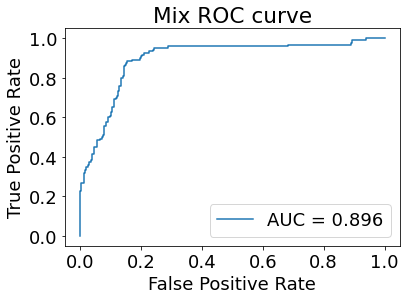

AUC: 0.896
Optimal threshold: 0.465


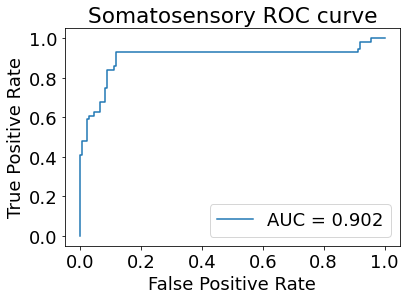

AUC: 0.902
Optimal threshold: 0.642


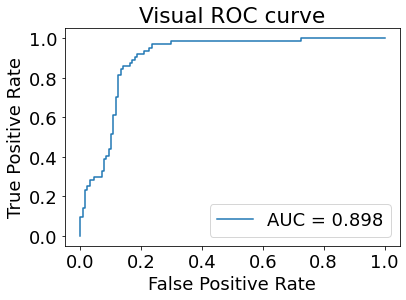

AUC: 0.898
Optimal threshold: 0.319


In [20]:
#train_fpr, train_tpr, train_thr = plot_roc(train_pred, train_target, "TRAINING")
#valid_fpr, valid_tpr, valid_thr = plot_roc(valid_pred, valid_target, "VALIDATION")
test_fpr_m, test_tpr_m, test_thr_m   = plot_roc(test_pred, test_target, "Mix")
test_fpr_s, test_tpr_s, test_thr_s   = plot_roc(test_pred[:int(test_pred.shape[0]/2)], test_target[:int(test_pred.shape[0]/2)], "Somatosensory")
test_fpr_v, test_tpr_v, test_thr_v   = plot_roc(test_pred[int(test_pred.shape[0]/2):], test_target[int(test_pred.shape[0]/2):], "Visual")

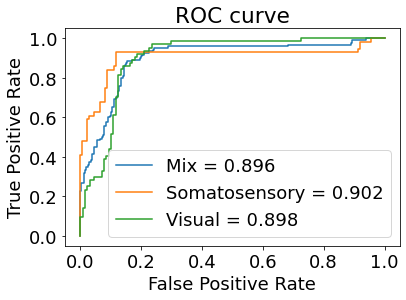

In [21]:
AUC = roc_auc_score(test_target, test_pred)
plt.plot(test_fpr_m, test_tpr_m, label="Mix = {:.3f}".format(AUC))
AUC = roc_auc_score(test_target[:int(test_pred.shape[0]/2)], test_pred[:int(test_pred.shape[0]/2)])
plt.plot(test_fpr_s, test_tpr_s, label="Somatosensory = {:.3f}".format(AUC))
AUC = roc_auc_score(test_target[int(test_pred.shape[0]/2):], test_pred[int(test_pred.shape[0]/2):])
plt.plot(test_fpr_v, test_tpr_v, label="Visual = {:.3f}".format(AUC))
plt.title("ROC curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

(384,)


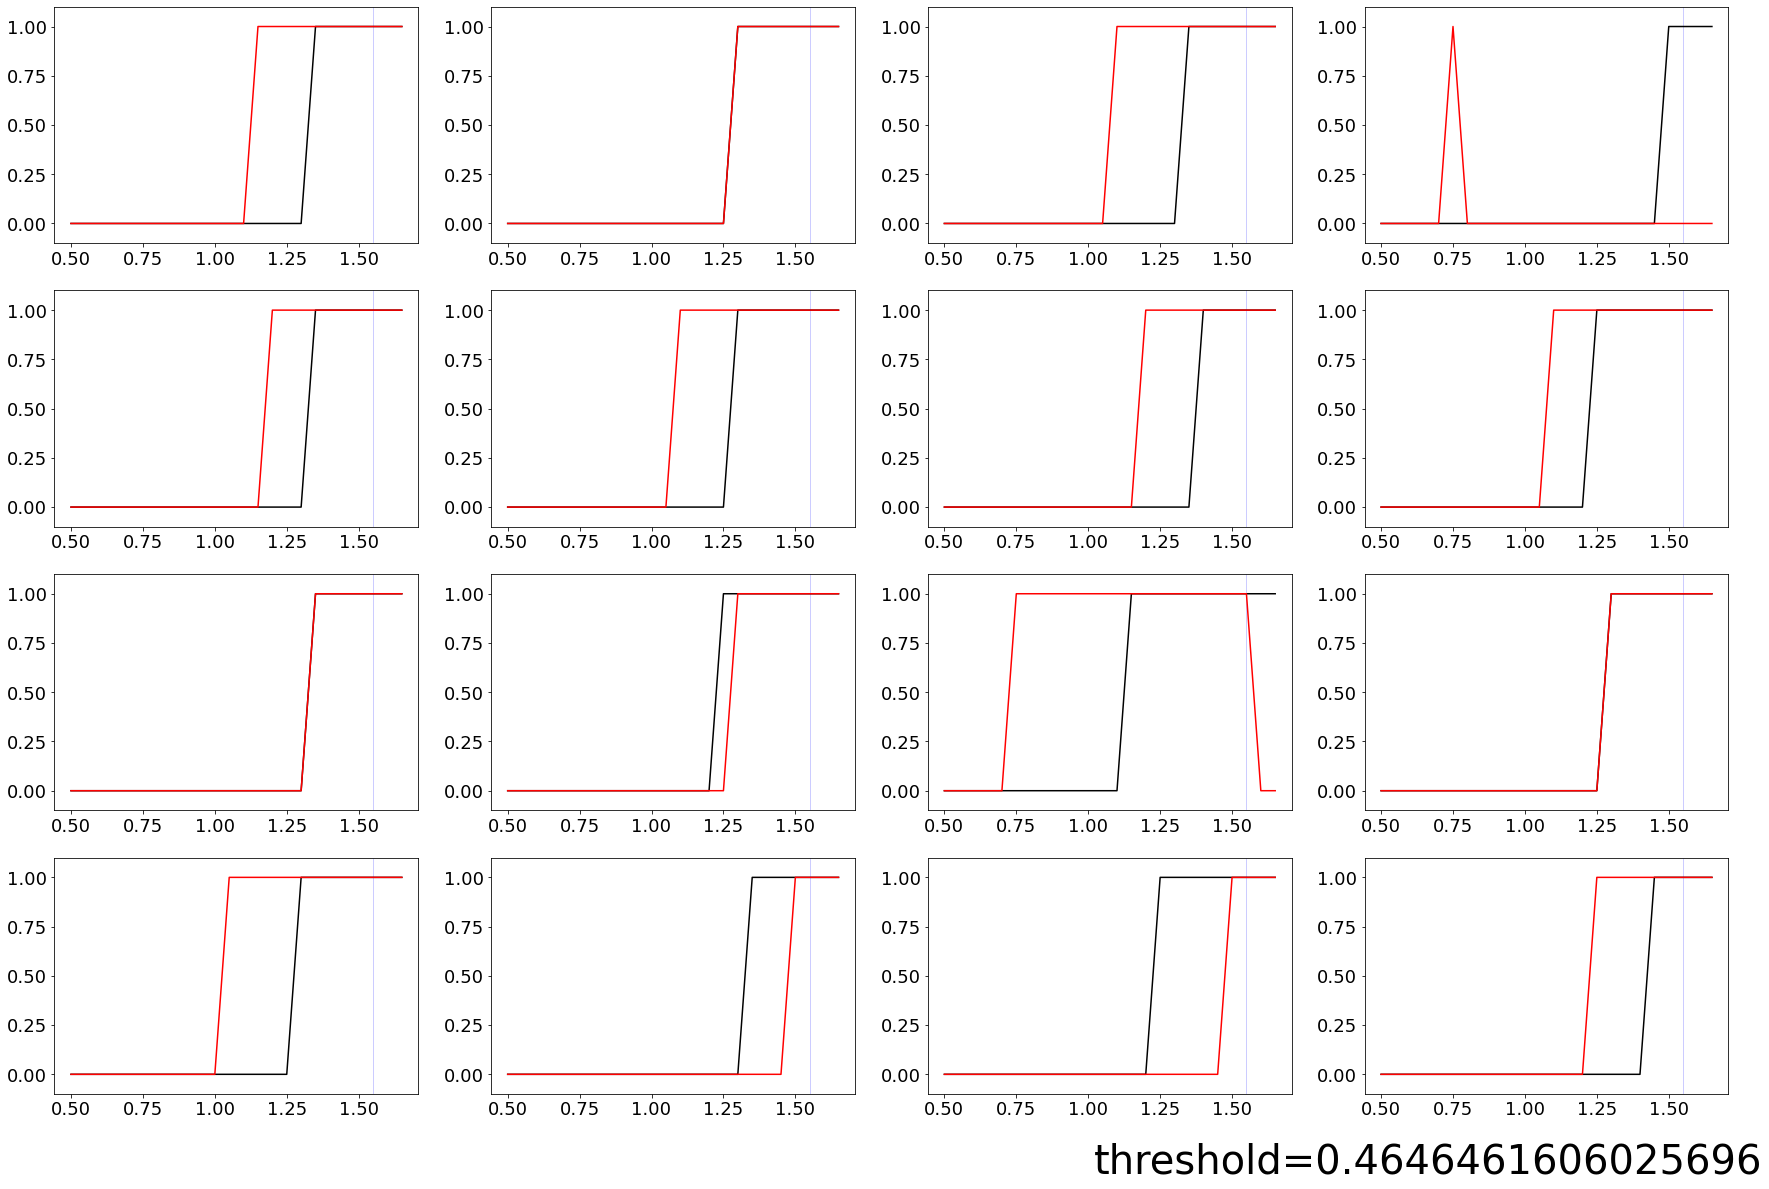

In [22]:
classified_mix_pred = []
for f in range(test_pred.shape[0]):
    if test_pred[f, 0] > test_thr_m:
        classified_mix_pred.append(1)
    else:
        classified_mix_pred.append(0)

classified_mix_pred = np.array(classified_mix_pred)
print(classified_mix_pred.shape)


plt.figure(figsize=(30, 20))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(test_target.shape[0]/prediction_frames)):
    plt.subplot(4, 4, ex+1)
    plt.plot(t, test_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, classified_mix_pred[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
    plt.axvspan(1.55, 1.55, color='blue', alpha=0.2)
    plt.ylim(-0.1, 1.1)

plt.text(-0.5, -0.5, f"threshold={test_thr_m}", fontsize=40, color="black")
plt.show()

(192,)


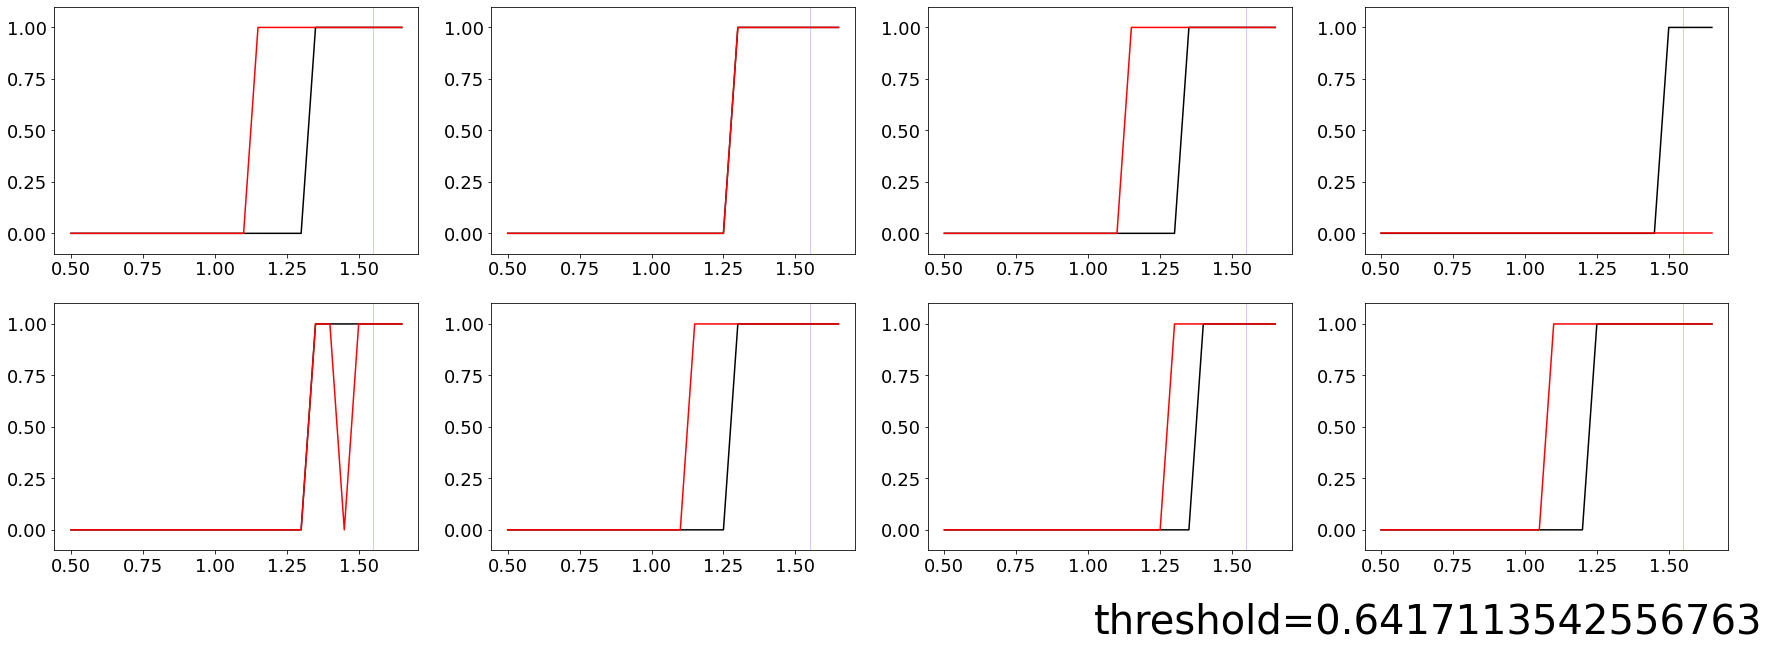

In [23]:
somato_pred = test_pred[:int(test_pred.shape[0]/2)]

classified_somato_pred = []
for f in range(somato_pred.shape[0]):
    if somato_pred[f, 0] > test_thr_s:
        classified_somato_pred.append(1)
    else:
        classified_somato_pred.append(0)

classified_somato_pred = np.array(classified_somato_pred)
print(classified_somato_pred.shape)


plt.figure(figsize=(30, 10))  # 幅12インチ、高さ8インチのFigureを作成

somato_target = test_target[:int(test_pred.shape[0]/2)]

for ex in range(int(somato_target.shape[0]/prediction_frames)):
    plt.subplot(2, 4, ex+1)
    plt.plot(t, somato_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, classified_somato_pred[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
    plt.axvspan(1.55, 1.55, color='blue', alpha=0.2)
    plt.ylim(-0.1, 1.1)

plt.text(-0.5, -0.5, f"threshold={test_thr_s}", fontsize=40, color="black")    
plt.show()

(192,)


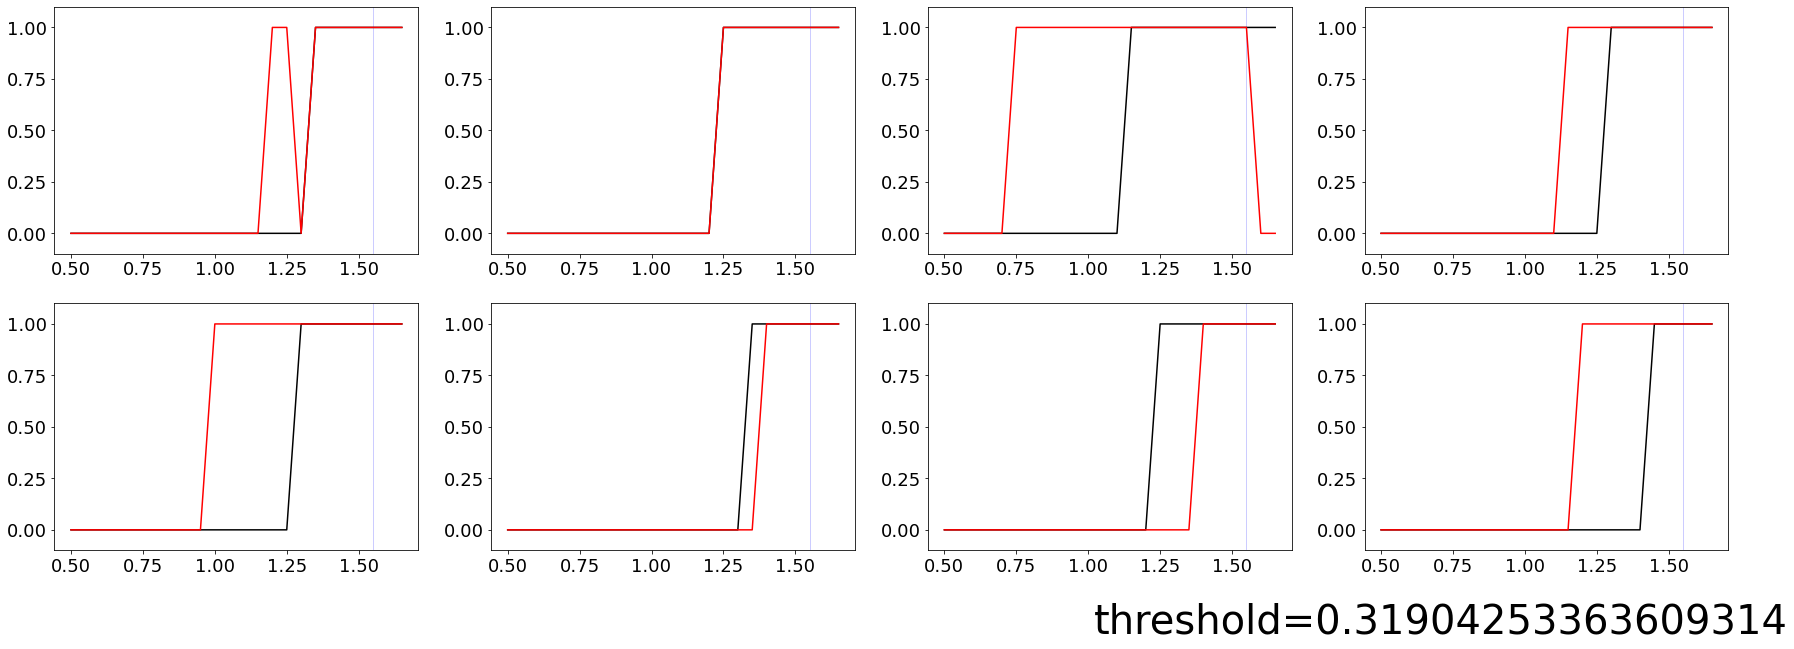

In [24]:
visual_pred = test_pred[int(test_pred.shape[0]/2):]

classified_visual_pred = []
for f in range(visual_pred.shape[0]):
    if visual_pred[f, 0] > test_thr_v:
        classified_visual_pred.append(1)
    else:
        classified_visual_pred.append(0)

classified_visual_pred = np.array(classified_visual_pred)
print(classified_visual_pred.shape)


plt.figure(figsize=(30, 10))  # 幅12インチ、高さ8インチのFigureを作成

visual_target = test_target[int(test_pred.shape[0]/2):]

for ex in range(int(visual_target.shape[0]/prediction_frames)):
    plt.subplot(2, 4, ex+1)
    plt.plot(t, visual_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, classified_visual_pred[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
    plt.axvspan(1.55, 1.55, color='blue', alpha=0.2)
    plt.ylim(-0.1, 1.1)

plt.text(-0.5, -0.5, f"threshold={test_thr_v}", fontsize=40, color="black")     
plt.show()

(384,)


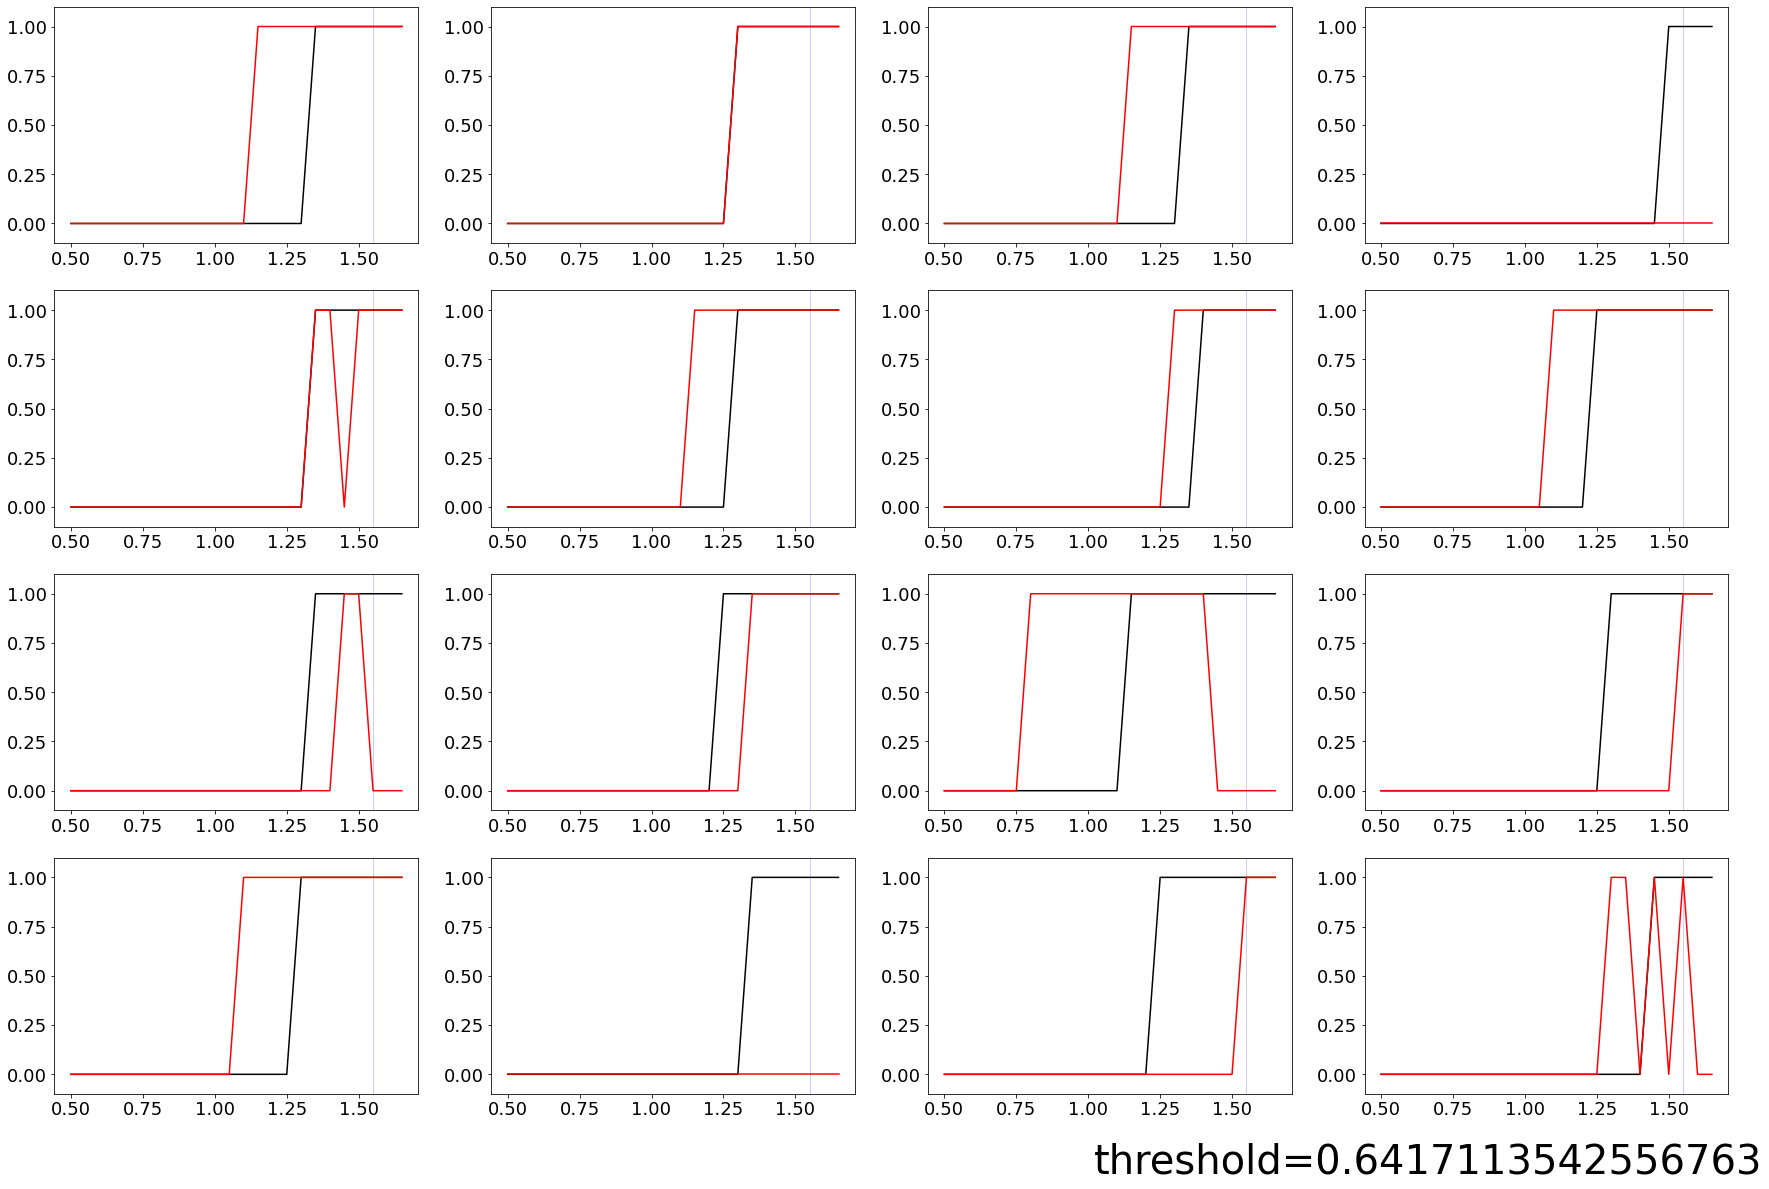

In [25]:
classified_mix_pred_2 = []
for f in range(test_pred.shape[0]):
    if test_pred[f, 0] > test_thr_s:
        classified_mix_pred_2.append(1)
    else:
        classified_mix_pred_2.append(0)

classified_mix_pred_2 = np.array(classified_mix_pred_2)
print(classified_mix_pred_2.shape)


plt.figure(figsize=(30, 20))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(test_target.shape[0]/prediction_frames)):
    plt.subplot(4, 4, ex+1)
    plt.plot(t, test_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, classified_mix_pred_2[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
    plt.axvspan(1.55, 1.55, color='blue', alpha=0.2)
    plt.ylim(-0.1, 1.1)

plt.text(-0.5, -0.5, f"threshold={test_thr_s}", fontsize=40, color="black")
plt.show()

(384,)


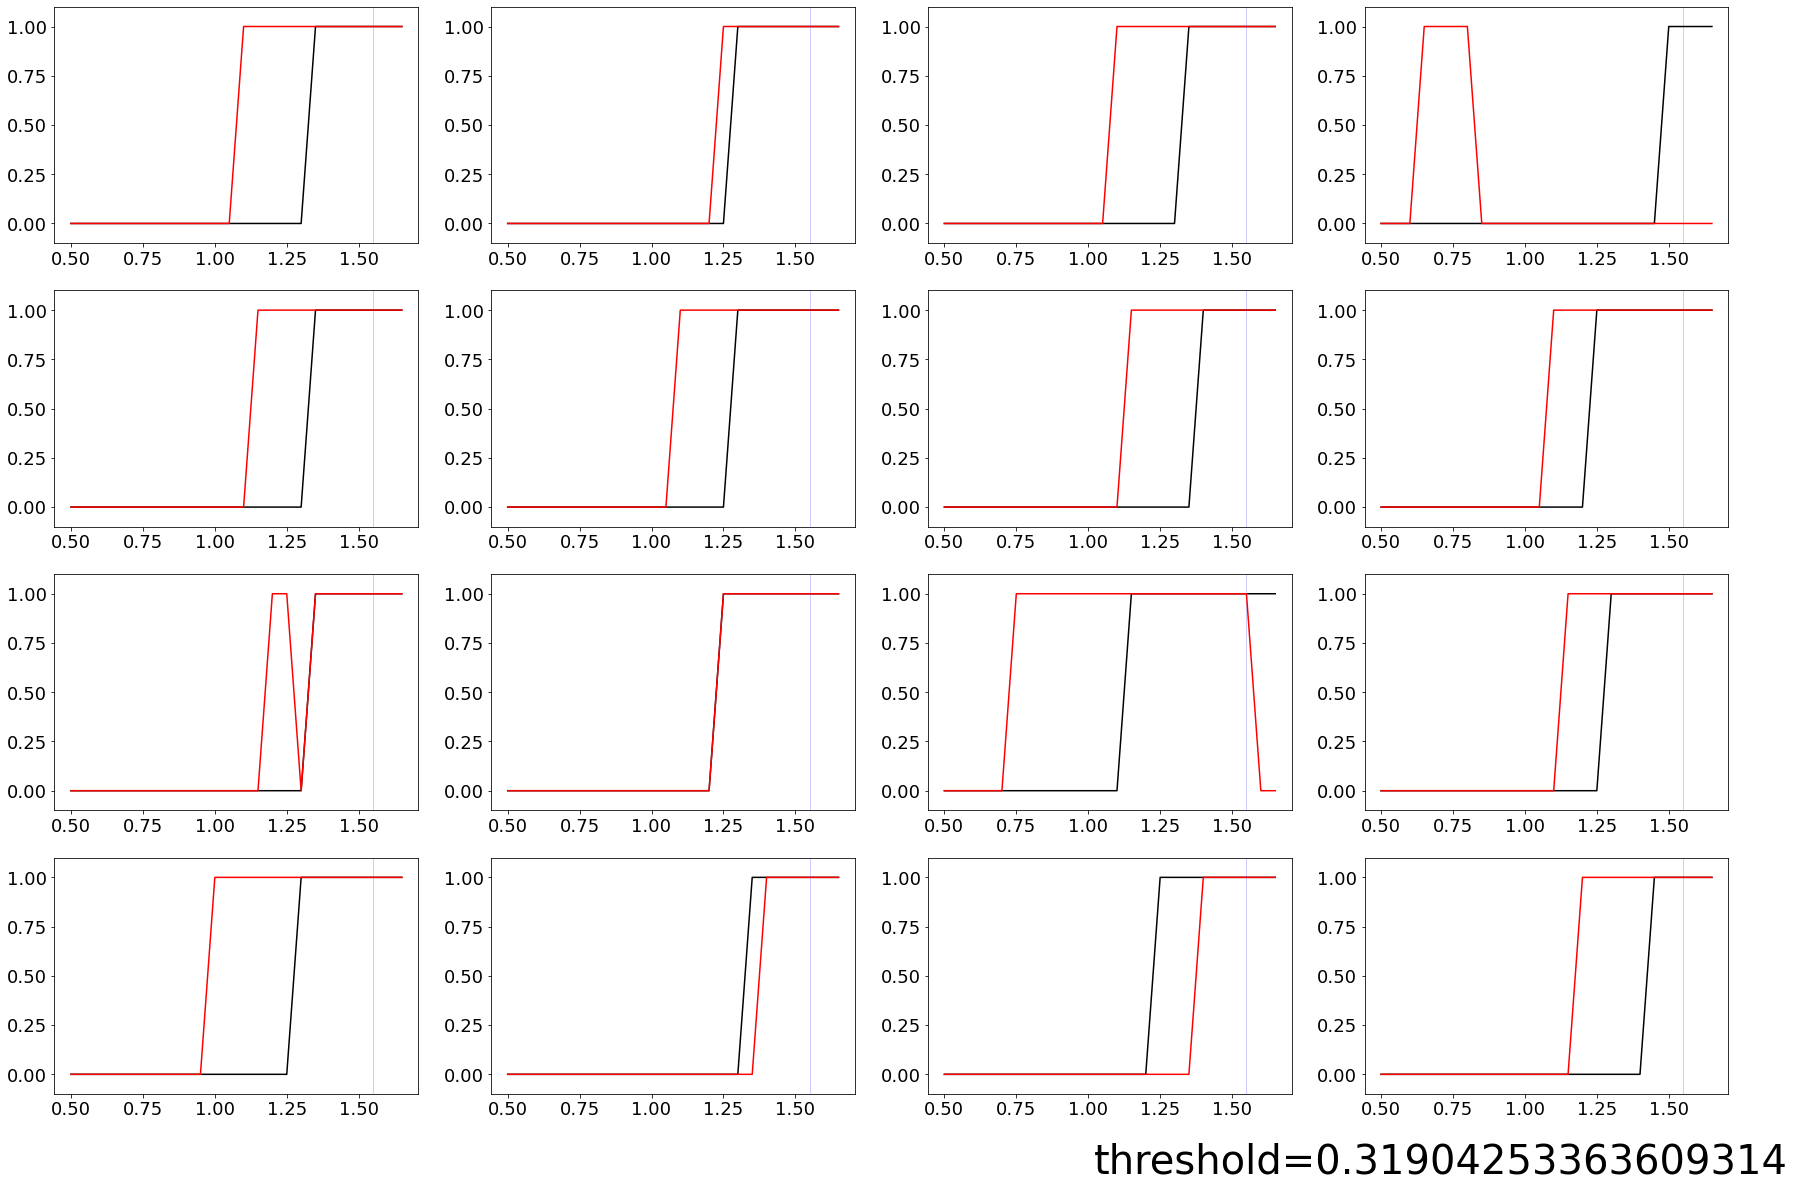

In [26]:
classified_mix_pred_3 = []
for f in range(test_pred.shape[0]):
    if test_pred[f, 0] > test_thr_v:
        classified_mix_pred_3.append(1)
    else:
        classified_mix_pred_3.append(0)

classified_mix_pred_3 = np.array(classified_mix_pred_3)
print(classified_mix_pred_3.shape)


plt.figure(figsize=(30, 20))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(test_target.shape[0]/prediction_frames)):
    plt.subplot(4, 4, ex+1)
    plt.plot(t, test_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, classified_mix_pred_3[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
    plt.axvspan(1.55, 1.55, color='blue', alpha=0.2)
    plt.ylim(-0.1, 1.1)

plt.text(-0.5, -0.5, f"threshold={test_thr_v}", fontsize=40, color="black")
plt.show()

In [27]:
ex_acc_array = []
for ex in range(int(test_target.shape[0]/prediction_frames)):
    if np.all(classified_mix_pred[ex*prediction_frames:(ex+1)*prediction_frames] < 1):
        ex_acc_array.append(0)
    else:
        ex_acc_array.append(1)

ex_acc_array = np.array(ex_acc_array)
ex_accuracy  = np.sum(ex_acc_array)/ex_acc_array.shape[0]


ex_acc_array_s = []
for ex in range(int(somato_target.shape[0]/prediction_frames)):
    if np.all(classified_somato_pred[ex*prediction_frames:(ex+1)*prediction_frames] < 1):
        ex_acc_array_s.append(0)
    else:
        ex_acc_array_s.append(1)

ex_acc_array_s = np.array(ex_acc_array_s)
ex_accuracy_s  = np.sum(ex_acc_array_s)/ex_acc_array_s.shape[0]


ex_acc_array_v = []
for ex in range(int(visual_target.shape[0]/prediction_frames)):
    if np.all(classified_visual_pred[ex*prediction_frames:(ex+1)*prediction_frames] < 1):
        ex_acc_array_v.append(0)
    else:
        ex_acc_array_v.append(1)

ex_acc_array_v = np.array(ex_acc_array_v)
ex_accuracy_v  = np.sum(ex_acc_array_v)/ex_acc_array_v.shape[0]

print(ex_accuracy)
print(ex_accuracy_s)
print(ex_accuracy_v)

1.0
0.875
1.0


In [28]:
acc_array = []
for f in range(classified_mix_pred.shape[0]):
    if classified_mix_pred[f] == test_target[f]:
        acc_array.append(1)
    else:
        acc_array.append(0)

acc_array = np.array(acc_array)
accuracy  = np.sum(acc_array)/acc_array.shape[0]

acc_array_s = []
for f in range(classified_somato_pred.shape[0]):
    if classified_somato_pred[f] == somato_target[f]:
        acc_array_s.append(1)
    else:
        acc_array_s.append(0)

acc_array_s = np.array(acc_array_s)
accuracy_s  = np.sum(acc_array_s)/acc_array_s.shape[0]

acc_array_v = []
for f in range(classified_visual_pred.shape[0]):
    if classified_visual_pred[f] == visual_target[f]:
        acc_array_v.append(1)
    else:
        acc_array_v.append(0)

acc_array_v = np.array(acc_array_v)
accuracy_v  = np.sum(acc_array_v)/acc_array_v.shape[0]

print(accuracy)
print(accuracy_s)
print(accuracy_v)

0.8541666666666666
0.890625
0.84375


In [29]:
ex_acc_array_1 = []
for ex in range(int(test_target.shape[0]/prediction_frames)):
    if np.all(classified_mix_pred[ex*prediction_frames:(ex+1)*prediction_frames] < 1):
        ex_acc_array_1.append(0)
    else:
        ex_acc_array_1.append(1)

ex_acc_array_1 = np.array(ex_acc_array_1)
ex_accuracy_1_s  = np.sum(ex_acc_array_1[:int(ex_acc_array_1.shape[0]/2)]) / int(ex_acc_array_1.shape[0]/2)
ex_accuracy_1_v  = np.sum(ex_acc_array_1[int(ex_acc_array_1.shape[0]/2):]) / int(ex_acc_array_1.shape[0]/2)


ex_acc_array_2 = []
for ex in range(int(test_target.shape[0]/prediction_frames)):
    if np.all(classified_mix_pred_2[ex*prediction_frames:(ex+1)*prediction_frames] < 1):
        ex_acc_array_2.append(0)
    else:
        ex_acc_array_2.append(1)

ex_acc_array_2 = np.array(ex_acc_array_2)
ex_accuracy_2_s  = np.sum(ex_acc_array_2[:int(ex_acc_array_2.shape[0]/2)]) / int(ex_acc_array_2.shape[0]/2)
ex_accuracy_2_v  = np.sum(ex_acc_array_2[int(ex_acc_array_2.shape[0]/2):]) / int(ex_acc_array_2.shape[0]/2)


ex_acc_array_3 = []
for ex in range(int(test_target.shape[0]/prediction_frames)):
    if np.all(classified_mix_pred_3[ex*prediction_frames:(ex+1)*prediction_frames] < 1):
        ex_acc_array_3.append(0)
    else:
        ex_acc_array_3.append(1)

ex_acc_array_3 = np.array(ex_acc_array_3)
ex_accuracy_3_s  = np.sum(ex_acc_array_3[:int(ex_acc_array_3.shape[0]/2)]) / int(ex_acc_array_3.shape[0]/2)
ex_accuracy_3_v  = np.sum(ex_acc_array_3[int(ex_acc_array_3.shape[0]/2):]) / int(ex_acc_array_3.shape[0]/2)

print(ex_accuracy_1_s, ex_accuracy_1_v)
print(ex_accuracy_2_s, ex_accuracy_2_v)
print(ex_accuracy_3_s, ex_accuracy_3_v)

1.0 1.0
0.875 0.875
1.0 1.0


In [30]:
acc_array_1 = []
for f in range(classified_mix_pred.shape[0]):
    if classified_mix_pred[f] == test_target[f]:
        acc_array_1.append(1)
    else:
        acc_array_1.append(0)

acc_array_1 = np.array(acc_array_1)
accuracy_1_s  = np.sum(acc_array_1[:int(acc_array_1.shape[0]/2)])/int(acc_array_1.shape[0]/2)
accuracy_1_v  = np.sum(acc_array_1[int(acc_array_1.shape[0]/2):])/int(acc_array_1.shape[0]/2)


acc_array_2 = []
for f in range(classified_mix_pred_2.shape[0]):
    if classified_mix_pred_2[f] == test_target[f]:
        acc_array_2.append(1)
    else:
        acc_array_2.append(0)

acc_array_2 = np.array(acc_array_2)
accuracy_2_s  = np.sum(acc_array_2[:int(acc_array_2.shape[0]/2)])/int(acc_array_2.shape[0]/2)
accuracy_2_v  = np.sum(acc_array_2[int(acc_array_2.shape[0]/2):])/int(acc_array_2.shape[0]/2)


acc_array_3 = []
for f in range(classified_mix_pred_3.shape[0]):
    if classified_mix_pred_3[f] == test_target[f]:
        acc_array_3.append(1)
    else:
        acc_array_3.append(0)

acc_array_3 = np.array(acc_array_3)
accuracy_3_s  = np.sum(acc_array_3[:int(acc_array_3.shape[0]/2)])/int(acc_array_3.shape[0]/2)
accuracy_3_v  = np.sum(acc_array_3[int(acc_array_3.shape[0]/2):])/int(acc_array_3.shape[0]/2)

print(accuracy_1_s, accuracy_1_v)
print(accuracy_2_s, accuracy_2_v)
print(accuracy_3_s, accuracy_3_v)

0.8541666666666666 0.8541666666666666
0.890625 0.7604166666666666
0.8177083333333334 0.84375


In [31]:
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_truth_test_mix.npy", test_target)
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_prediction_test_mix.npy", test_pred)

In [ ]:
import shap
import numpy


def calc_shap(input_data, data_pred, model):
    #num_data = 1*100  # background sample number (about 1/20)
    #num_data = int(input_data.shape[0]/20)  # background sample number (about 1/20)
    #data_idx = numpy.random.choice(range(input_data.shape[0]), num_data, replace=False)
    data_idx = np.array(list(range(0, input_data.shape[0], 20)))
    base = data_pred[data_idx].mean()
    explainer = shap.DeepExplainer(model, input_data[data_idx])
    shap_val = numpy.zeros(input_data.shape)
    
    # calculate shap value of all data
    BATCH_SIZE = 100
    for idx in range(input_data.shape[0] // BATCH_SIZE + 1):
        if idx != input_data.shape[0] // BATCH_SIZE:
            bs = BATCH_SIZE
        else:
            bs = input_data.shape[0] % BATCH_SIZE
        input_shap = input_data[idx * BATCH_SIZE:(idx) * BATCH_SIZE + bs]
        shap_val[idx * BATCH_SIZE:(idx) * BATCH_SIZE + bs] = numpy.array(explainer.shap_values(input_shap))
    
    return shap_val, base


In [37]:
import tqdm

shap_vals = np.zeros_like(input_test)

bases = []
for ex in tqdm.tqdm(range(len(TEST))):
    ex_frames = int(input_test.shape[0]/len(TEST))
    input_data = input_test[ex*ex_frames:(ex+1)*ex_frames]
    test_pred = model.predict(input_data)
    shap_val, base = calc_shap(input_data, test_pred, model)
    shap_vals[ex*ex_frames:(ex+1)*ex_frames] = np.array(shap_val)
    bases.append(base)
    
base = np.mean(bases)

100%|██████████| 8/8 [00:24<00:00,  3.05s/it]


In [38]:
io.savemat(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_shap_{ver}.mat", {"base":base, "shap":shap_vals, "pred":test_pred, "label":testY})
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_shap_values.npy", shap_vals)